<a href="https://colab.research.google.com/github/sskarthik0801/ME-597-IIOT/blob/main/lab/lab4/L4_Colab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab4/L4_Colab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4.2 MTConnect Practice

## 2.1 Run MTConnect Agent on Laptop

Now, we are ready to run MTConnect agent. First, we will run MTConnect agent on laptop without change from the given configurations. Please follow the direction below.


1.	Open ‘Command Prompt’.
2.	Change directory by ‘cd’ and \<file directory> command as below:

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_Windows.png?raw=tru" width="20">Windows - Command Prompt**

`cd <agent file directory>`

* In the example below, the file directory is C:\agent_Windows

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab4_fig0-1.png?raw=true" width="40%">

---

3. (Optional) To see the contents in the directory, use ‘dir’ command.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab4_fig0-2.png?raw=true" width="40%">

4.	Run MTConnect agent by ‘agent.exe run’ command.

  a.	If ‘Windows Security Alert’ pops up, click ‘Allow access’.

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_Windows.png?raw=tru" width="20">Windows - Command Prompt**

`agent.exe run`
* If you want to run agent as a debug mode, use agent.exe debug.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S26_update/Lab4_fig0.PNG?raw=true" width="80%">

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab4_fig0-4.png?raw=true" width="50%">

---

5.	To check MTConnect agent that you run, open a web-browser on laptop, and then type ‘localhost:5000’ on the address bar.

  a.	If you see the capture below, you succeed to run MTConnect agent!

  b.	Other IP address should work such as ‘127.0.0.1:5000’ and ‘your IP address:5000’

  c.	This request provides MTConnect properties that is defined in ‘Device.xml’.

  d.	Try to compare ‘Device.xml’ and the request.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab4_fig0-5.png?raw=true" width="100%">


6.	Try 3 different data collection methods below.
7.	To close (halt) the agent service, press Ctrl + c on ‘Command Prompt’.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab4_fig0-6.png?raw=true" width="60%">






**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_Tip.png?raw=tru" width="20">Tip - Data Collection Method**


Data collection methods may vary depending on the client applications’ needs but a general method of collecting data from an MTConnect agent is described below. The method described is used to aggregate ‘ALL’ data from an MTConnect agent and ensure data is not duplicated in a data store and not missed in the agent buffer. All responses upon HTTP requests are XML documents.

Generally, there are 3 steps to collecting data from MTConnect.
1.	Map the properties (Probe the agent)

  a.	IP_Address:Port_Number/probe
    
    i.	Ex) http://127.0.0.1:5000/probe

  b.	Probe request provides device data model (Device.xml) – including dataitems and metadata
2.	Request ‘Current’ state of machine

  a.	IP_Address:Port_Number/current

    i.	Ex) http://127.0.0.1:5000/current

  b.	Current request provides current state (the latest) of ‘ALL’ dataitems
3.	Periodically get ‘ALL’ data from the agent from where you last left off and a reasonably large ‘count’ to ensure you get everything in the agent (you normally base this on the sample rate of the adapter)
  a. IP_Address:Port_Number/sample

    i. Ex) http://127.0.0.1:5000/sample

  b.	Sample request provides 100 samples (default) from the first sequence.

  c.	In addition, you’d like to request more samples and specify starting sequence, refer to the example below.

    i.	Ex) http://127.0.0.1:5000/sample?from=3&count=200
    
    ii.	This request getting the next 200 samples of data published to the agent from sequence number 3.

---


### Task 2.1


1.	Change port number in *‘agent.cfg’* from 5000 to 5001 of the agent and then run on laptop.
2.	Request *‘127.0.0.1:5001/current’* on a web browser of **laptop** and then capture and attach it below. If you get a **blank screen**, please see the following *'Blank screen solution'*.
3.	Request *‘IP_Address:5001/current’* on a web browser (*‘Chromium’*) of **Raspberry Pi** and then capture and attach it below. If you get any error, please try to turn off your fire walls on your laptop.

**Blank screen solution**: You may get a blank screen that nothing is shown in your browser.

* Method 1 : Press 'Ctrl+U' to see the page source of the URL.

* Method 2 :
1. Open your *'agent.cfg'* file using a text editor and do the following changes as shown in the following figure:
2.  In line 7, change *'Pretty = true'* to *'Pretty = false'*.
3.  Comment out the contents between line 18 (included) and line 35 (included).
Your updated *'agent.cfg'* file will look like the following figure.


<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S24_update/lab4_agent_cfg_update.png?raw=true" width="50%">

After making this change, you will see the XML file instead of the 'Pretty' style. However, both of them have the same information. If you cannot see the 'Pretty' style, you will use the XML sytle in the following labs. For the difference between the 'Pretty' style and the XML style, please see Figure 5 and Figure 6.

---

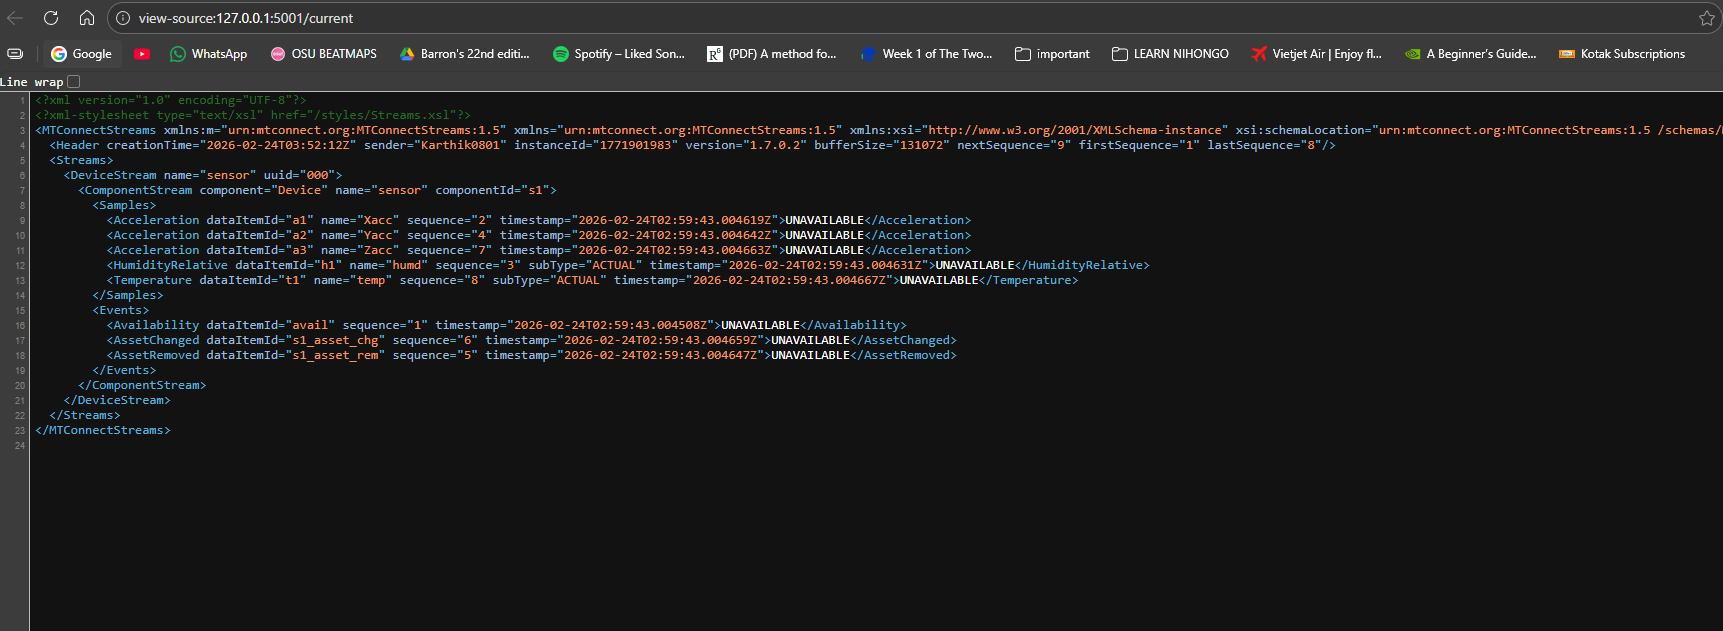

---

---

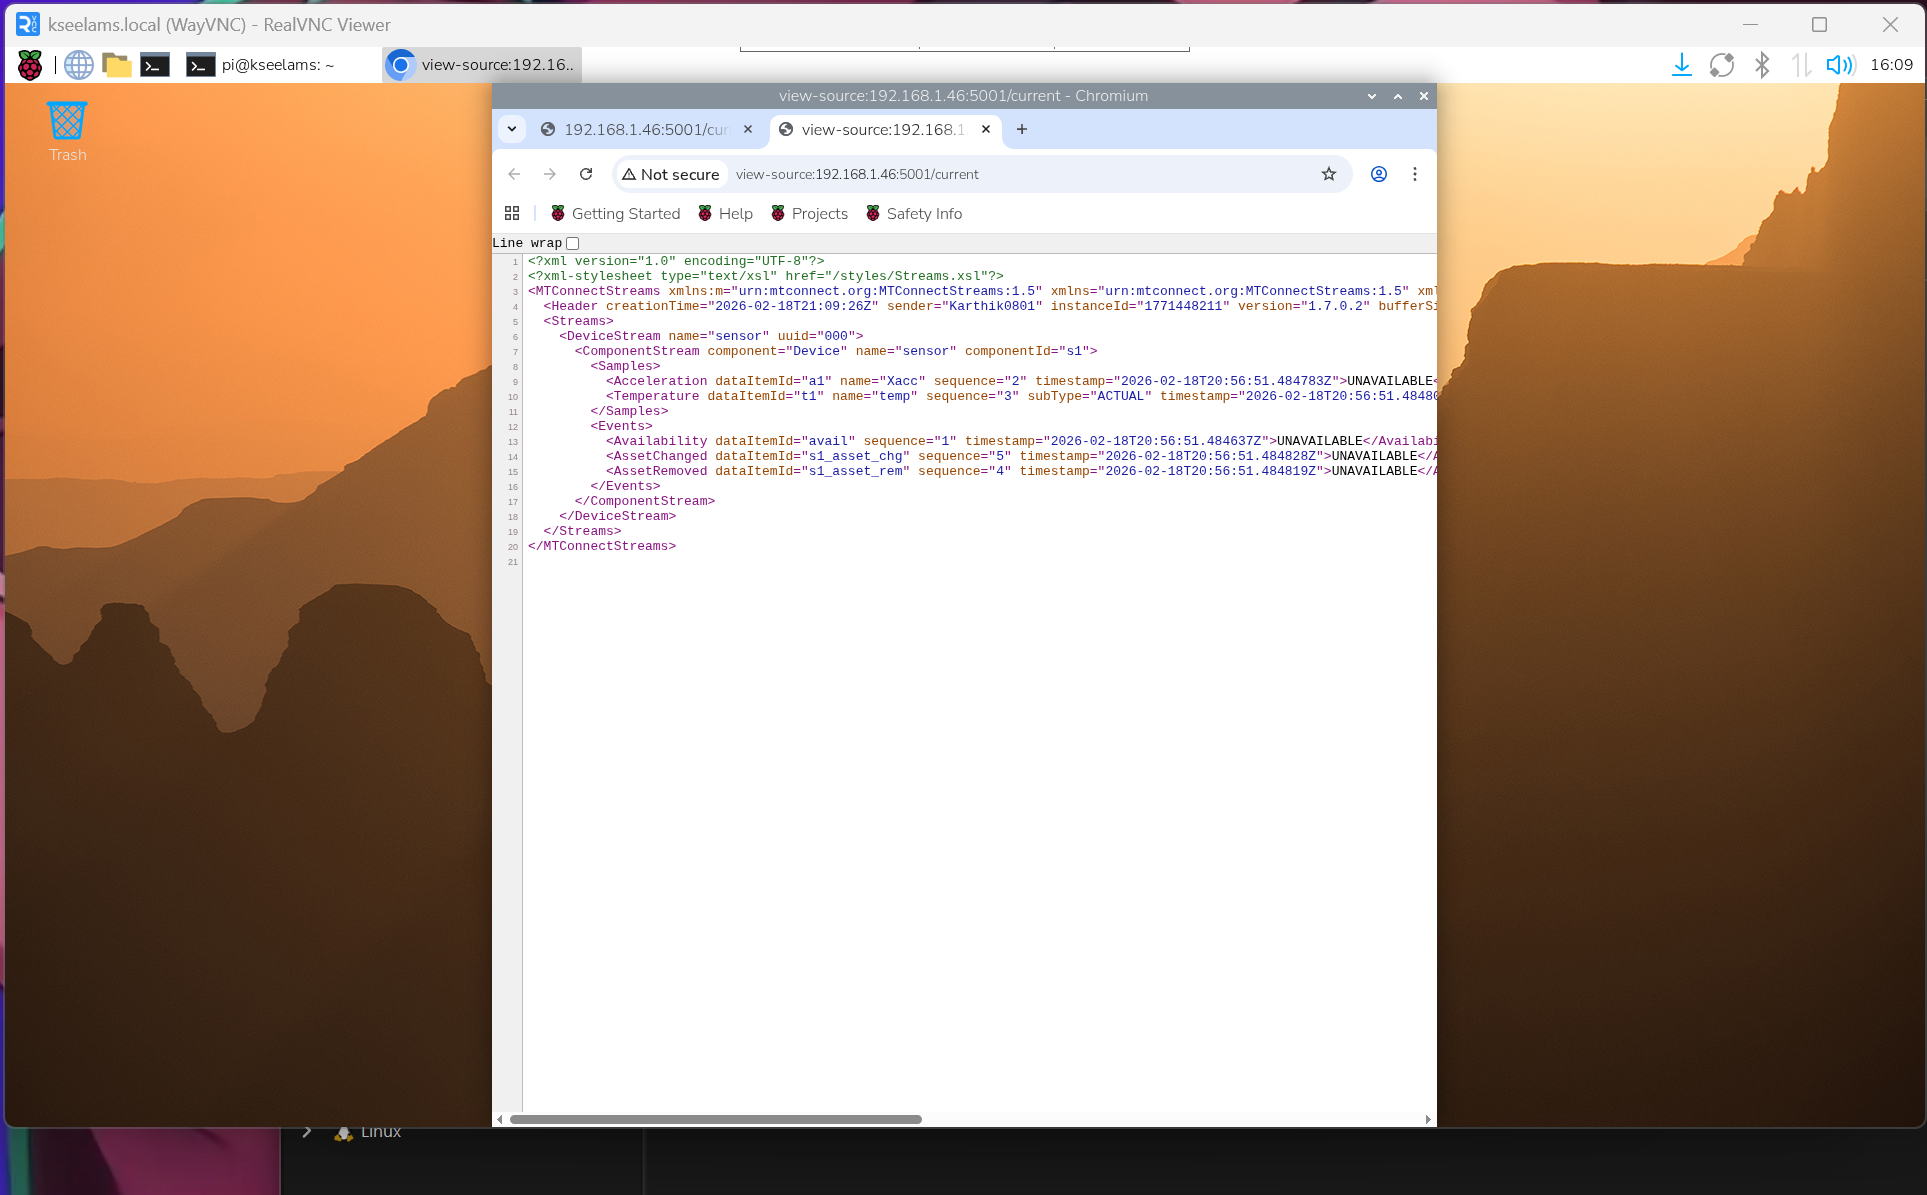

---

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_Tip.png?raw=tru" width="20">Tip - Change view of MTConnect agent data**

When you request using ‘current’ or ‘sample’ method, the response looks as in Figure 5. This is because of the styles how to show XML document. If you want to see data in XML document format as Figure 6, right click on the web browser and then click ‘View page source’.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab4_fig5.png?raw=true" width="70%">

*Figure 5 Default view of current data from agent*

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab4_fig6.png?raw=true" width="100%">


*Figure 6 XML document view of current data from agent*

---







### 2.2 Run MTConnect agent on Raspberry Pi

Let’s run MTConnect agent on Raspberry Pi. Please follow the steps below.
1.	Open ‘Terminal’.
2.	Change directory using ‘cd’ \<file directory> command as below.

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_RaspberryPi.png?raw=tru" width="20">Raspberry Pi - Terminal**

`cd /home/pi/agent_RaspberryPi/`

* In this example, the file directory is /home/pi/agent_RaspberryPi/.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab4_fig0-7.png?raw=true" width="40%">

* You must give execute permission before run program files.

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_RaspberryPi.png?raw=tru" width="20">Raspberry Pi - Terminal**

`sudo chmod 777 *`

---

3.	Run MTConnect agent by ‘sudo ./agent’ command.

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_RaspberryPi.png?raw=tru" width="20">Raspberry Pi - Terminal**

`sudo ./agent`

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S26_update/Lab4_fig6.PNG?raw=true" width="80%">

---

4.	To check MTConnect agent that you run, use a web browser.
5.	To close (halt) the agent service, press Ctrl + c on *‘Terminal’*.


### Task 2.2

1.	Change port number in ‘agent.cfg’ from 5000 to 5001 of the agent and then run on **Raspberry Pi**.
2.	Request *‘127.0.0.1:5001/current’* on a web browser of **Raspberry Pi** and then capture and attach it below.
3.	Request *‘Pi_IP_Address:5001/current’* on a web browser of **laptop** and then capture and attach it below.


---

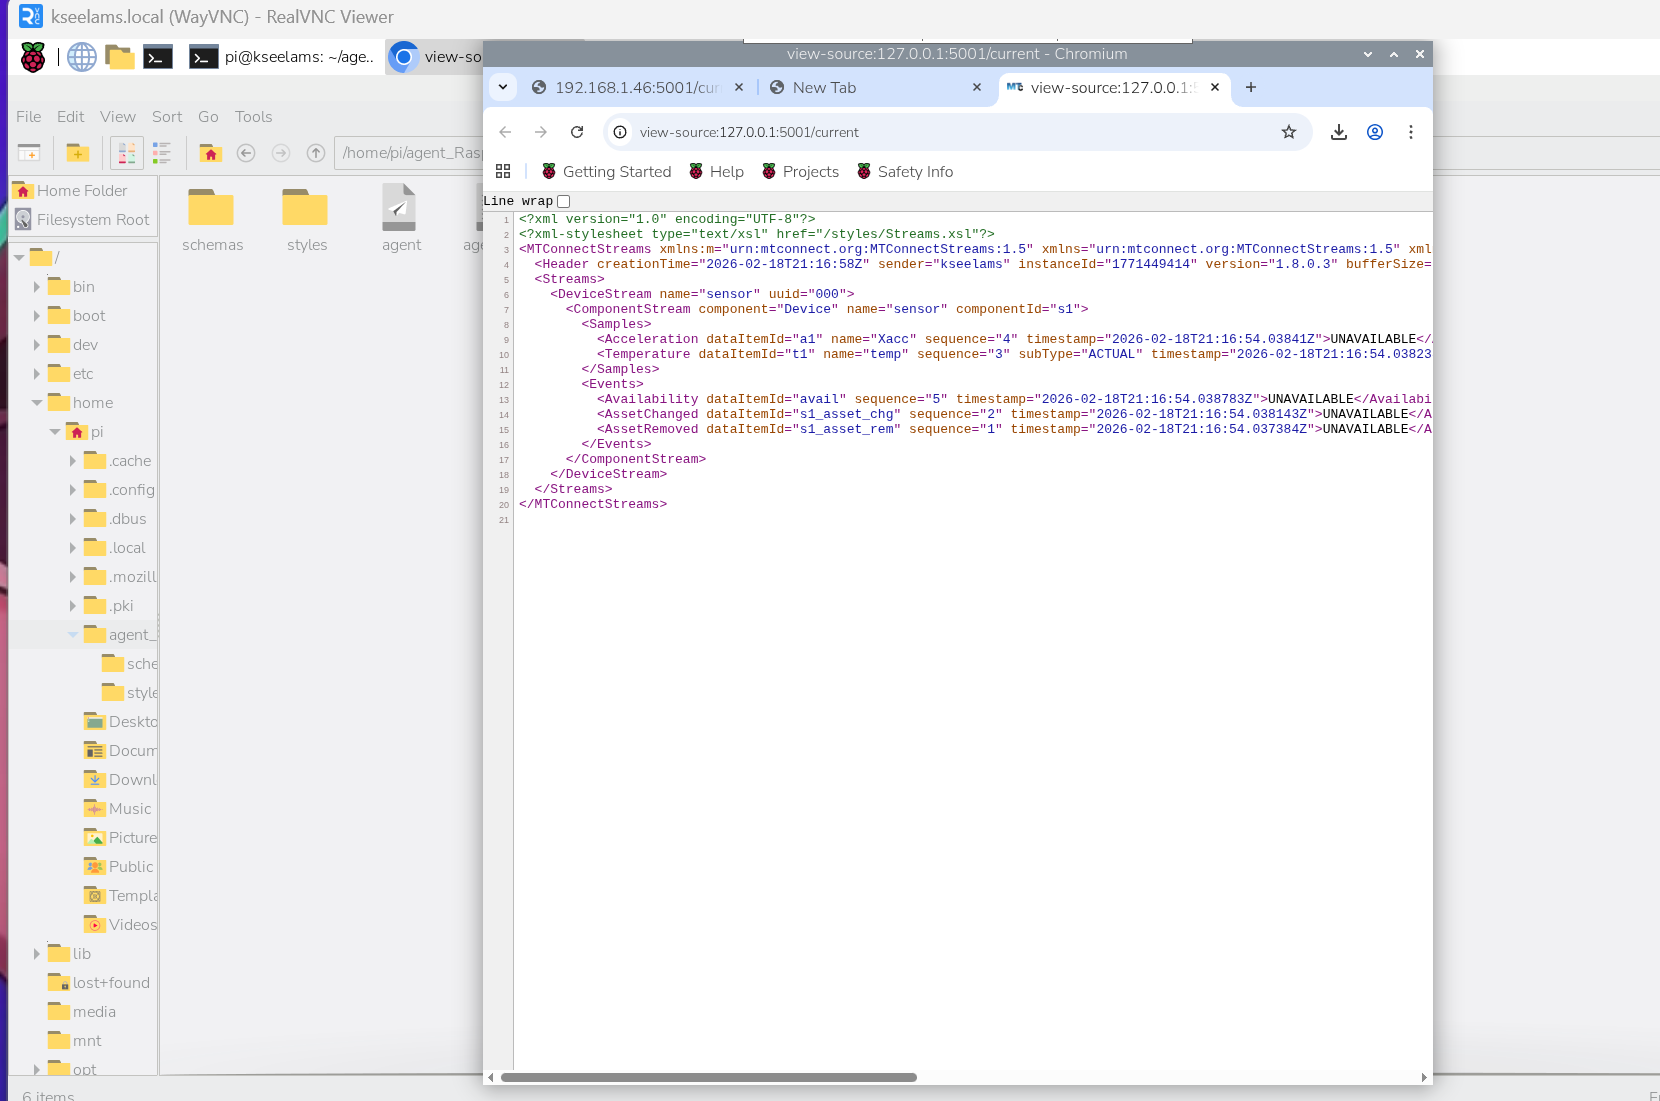

---

---

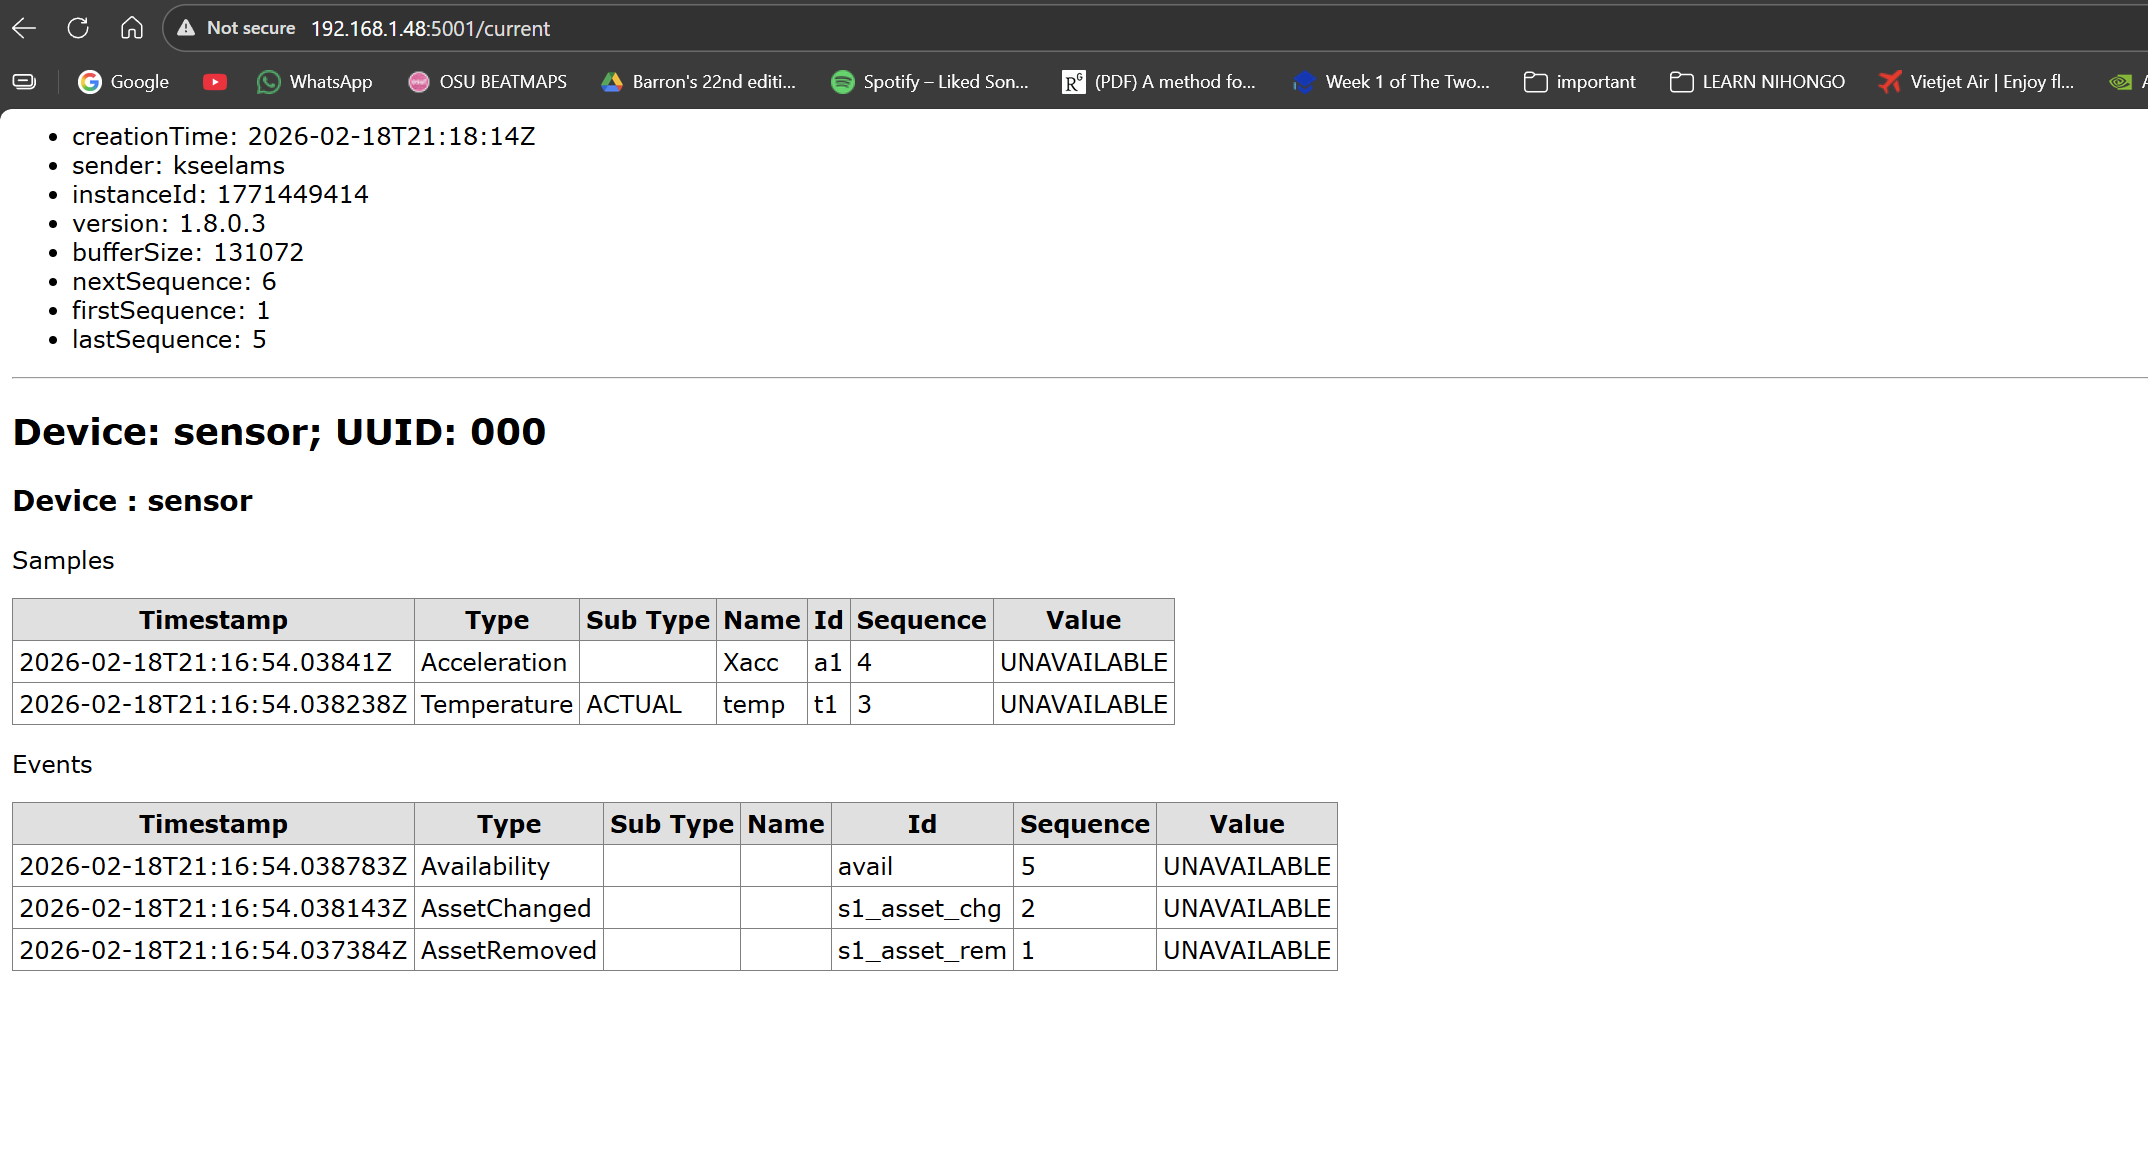

---

### 2.3 Modify device data model

In this part, we will change the device data model by modifying ‘Device.xml’. The given device model has 2 data items (id=”a1” and id=”t1”) because id=”avail” is a default EVENT data item for a device. The scenario is to make MTConnect agent (laptop) device data model to collect 3-axis accelerometer (ADXL345, Lab2) data and temperature sensor (DS18B20, Lab1) data from Raspberry Pi. Additionally, let's assume there are virtual sensor which detect humidity. Because the data items are measured values, the category must be SAMPLE. The device data model schematic is shown in Figure 7.  Therefore, your Raspberry Pi will be an MTConnect adapter and your laptop will be an MTConnect agent. Please follow the steps below.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S25_update/lab4_fig7.png?raw=true" width="80%">

*Figure 7 Device data model schematic*

1.	Open ‘Device.xml’ using any text editors on laptop.

  a.	You can use any kind of text editors, but Notepad++ ([download here](https://notepad-plus-plus.org/downloads/)) is recommended.
2.	Add 3 more ‘DeviceItem’ elements between Line 8 and 9 as below.

  a.	\<DataItem category="SAMPLE" id="a2" name="Yacc" type="ACCELERATION" units="MILLIMETER/SECOND2"/>
  
  b.	\<DataItem category="SAMPLE" id="a3" name="Zacc" type="ACCELERATION" units="MILLIMETER/SECOND2"/>

  c.	\<DataItem category="SAMPLE" id="h1" name="humd" type="HUMIDITY_RELATIVE" subType="ACTUAL" units="PERCENT"/>

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab4_fig0-9.png?raw=true" width="100%">

3. Save the file and then close


### Task 2.3

1.	Run the agent on laptop after modifying 'Device.xml' as Sec2.3 (above).
2.	Request ‘probe’ data on a web browser of either Raspberry Pi or laptop and then capture and attach it below.
3.	Request ‘current’ data on a web browser of either Raspberry Pi or laptop and then capture and attach it below.
4.	Confirm the added data items from the agent data by indicating on the captures.
  * Because there are no adapters, all values are ‘UNAVAILABLE’ now.



---

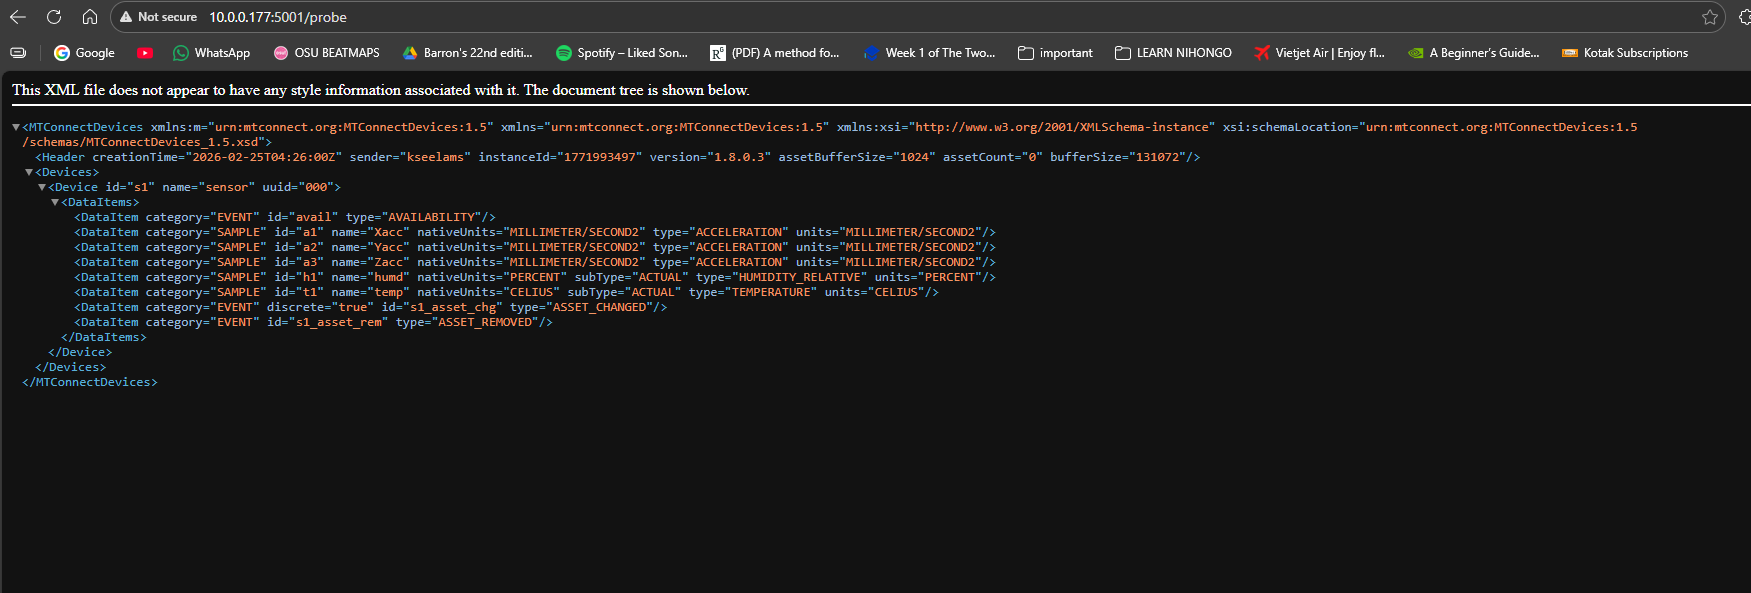

---

---

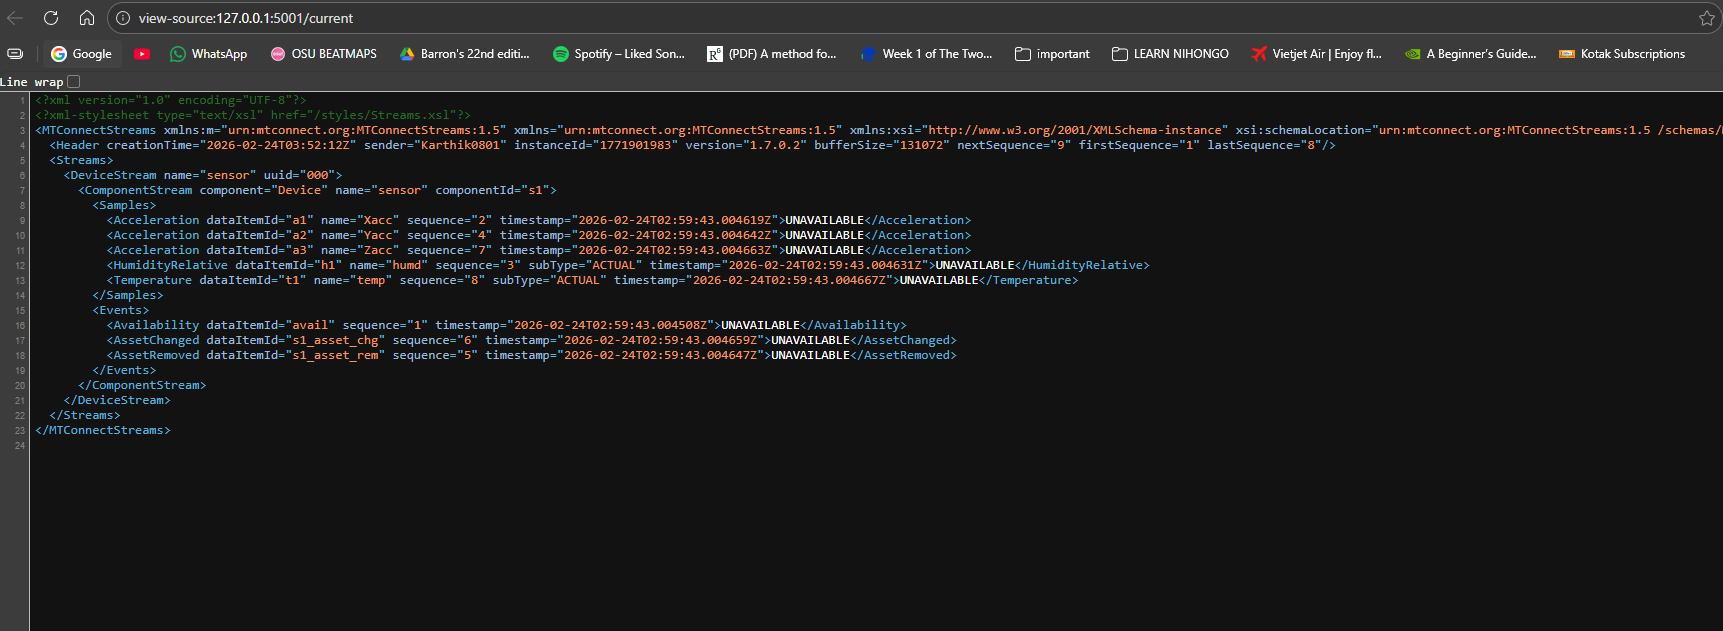

---

<br></br>

Please continue to [Lab 4.3 here](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab4/L4_Colab3.ipynb).